#    **OTOMOTİV SEKTÖRÜNDE MAKROEKONOMİK GÖSTERGELERE DUYARLI DİNAMİK TALEP VE TEDARİK ZİNCİRİ OPTİMİZASYONU**

# Yapay Zeka Tabanlı Prescriptive Analytics Karar Destek Sistemi Raporu

##   Geliştiren: Melike Kumanlı (YBS 4. Sınıf , 132230090)

     1. İş Probleminin Tanımı ve Maliyet Dengesi
Otomotiv tedarik zinciri yönetiminde en kritik konu, üretim parça tedariği ile pazar talebini dengede tutmaktır. Bu süreçte fabrika iki farklı maliyet riskiyle karşı karşıyadır:
Üretim Bandının Durma Maliyeti (Yok Satma): Eksik parça nedeniyle hattın durmasının araç başına maliyeti 50,000 TL'dir.
Depolama Maliyeti (Fazla Stok): Parçaların depoda fazladan kalmasının birim maliyeti aylık 5,000 TL'dir.Fabrika açısından bandın durma riski, fazla stok tutma riskine kıyasla 10 kat daha maliyetlidir. Standart tahmin modelleri bu asimetrik risk farkını hesaba katmaz; eksik tahmin ile fazla tahmini aynı ölçüde hatalı kabul eder.

Bu projede, pazar talebini tahmin etmenin ötesine geçerek, fabrikanın maliyet dengesine göre "En Optimum Güvenlik Stoğu Seviyesini" hesaplayan bir karar destek sistemi geliştirilmiştir.

     2. Veri Harmanlama (Data Fusion) ve Özellik Mühendisliği
Modelin pazar hareketlerini doğru analiz edebilmesi için iki farklı veri kaynağı Tarih bazında birleştirilmiştir:
Fabrika Operasyonel Verileri: Aylık Üretim Adedi, Ortalama Araç Fiyatı ve Gerçekleşen Satış Adetleri.
Makroekonomik Göstergeler: Türkiye pazarını yansıtan Dolar Kuru, Taşıt Kredisi Faiz Oranları ve Yıllık Enflasyon verileri.

Modelin ekonomik kırılmaları daha net yakalayabilmesi amacıyla 3 yeni değişken türetilmiştir:         

Kredi_Zorluk_Endeksi ($KZE$): $\frac{\text{Faiz} \times \text{Enflasyon}}{100}$ formülüyle hesaplanmış olup, tüketicilerin finansmana erişim sınırını temsil eder.

Dolar_Aylik_Artis_Hizi: Kur hareketlerine bağlı olarak tüketicilerin alımları öne çekme (panik alımı) eğilimini modele öğretir.

Son_3_Ay_Uretim_Trendi: Fabrikanın üretim momentumunu ve geçmişe dayalı zaman serisi bağımlılığını korur.

    3. Hibrit Modelleme Mimarisi (SARIMAX + Random Forest)

Pazardaki hem dönemsel etkileri hem de ani ekonomik değişiklikleri yakalamak adına Hibrit bir Ensemble yapı kurulmuştur:

SARIMAX: Sektörün geçmişe dayalı mevsimsel satış trendlerini (örneğin yıl sonu kampanya dönemlerindeki talep artışlarını) analiz eder.

Random Forest: Faiz artışı veya kur şoku gibi ani makroekonomik dalgalanmaları ve doğrusal olmayan ilişkileri çözer.

Model Başarı Kıyaslaması:Tekli Model (Random Forest) MAE Hatası: 87.56 Adet

      YENİ HİBRİT MODEL (SARIMAX + RF) MAE HATASI: 42.12 Adet

Açıklayıcılık Oranı ($R^2$ Score): %91.5 Mimarinin hibrit yapıya geçirilmesiyle, modelin tahmin hata payı %51.8 oranında azaltılmıştır.

    4. Açıklanabilir Yapay Zeka (XAI) ve SHAP Bulguları Modelin kararlarını şeffaf ve denetlenebilir hale getirmek amacıyla SHAP analizi kullanılmıştır.

 Elde edilen bulgular şunlardır:

 Mevcut Üretim Adedi: Modelin tahmin yaparken referen aldığı en güçlü operasyonel değişkendir.Kredi Zorluk Endeksi: Kendi ürettiğimiz iş mantığı değişkeni, ham faiz ve enflasyon sütunlarını geride bırakarak modeli etkileyen en önemli 2. faktör olmuştur. Bu durum, öznitelik mühendisliği adımının modele katkısını doğrulamaktadır.

 5. Finansal Simülasyon ve Sipariş Önerisi Modelden alınan 42 adetlik tahmin hatası, fabrikanın ceza maliyetlerini (50,000 TL ve 5,000 TL) baz alan finansal simülasyon modeline aktarılmıştır. Simülasyon, toplam risk maliyetini en düşük seviyede tutacak dengeli sipariş noktasını hesaplamıştır.

 Sistemin Karar Önerisi:  Model, önümüzdeki ay için ham talebi 3018 adet olarak öngörmüştür. Ancak üretim bandının durma riskini minimize etmek amacıyla sisteme %7.0 oranında bir Güvenlik Stoğu (+211 Adet) eklenmesini önermiş ve tedarikçiye verilmesi gereken nihai siparişi 3229 adet olarak belirlemiştir.

    Finansal Fayda
  Bu karar mekanizmasının uygulanmasıyla fabrikanın duruş riski optimize edilmiş ve simüle edilen pazar şartlarında yıllık ortalama 4.2 Milyon TL net tasarruf potansiyeli hesaplanmıştır.

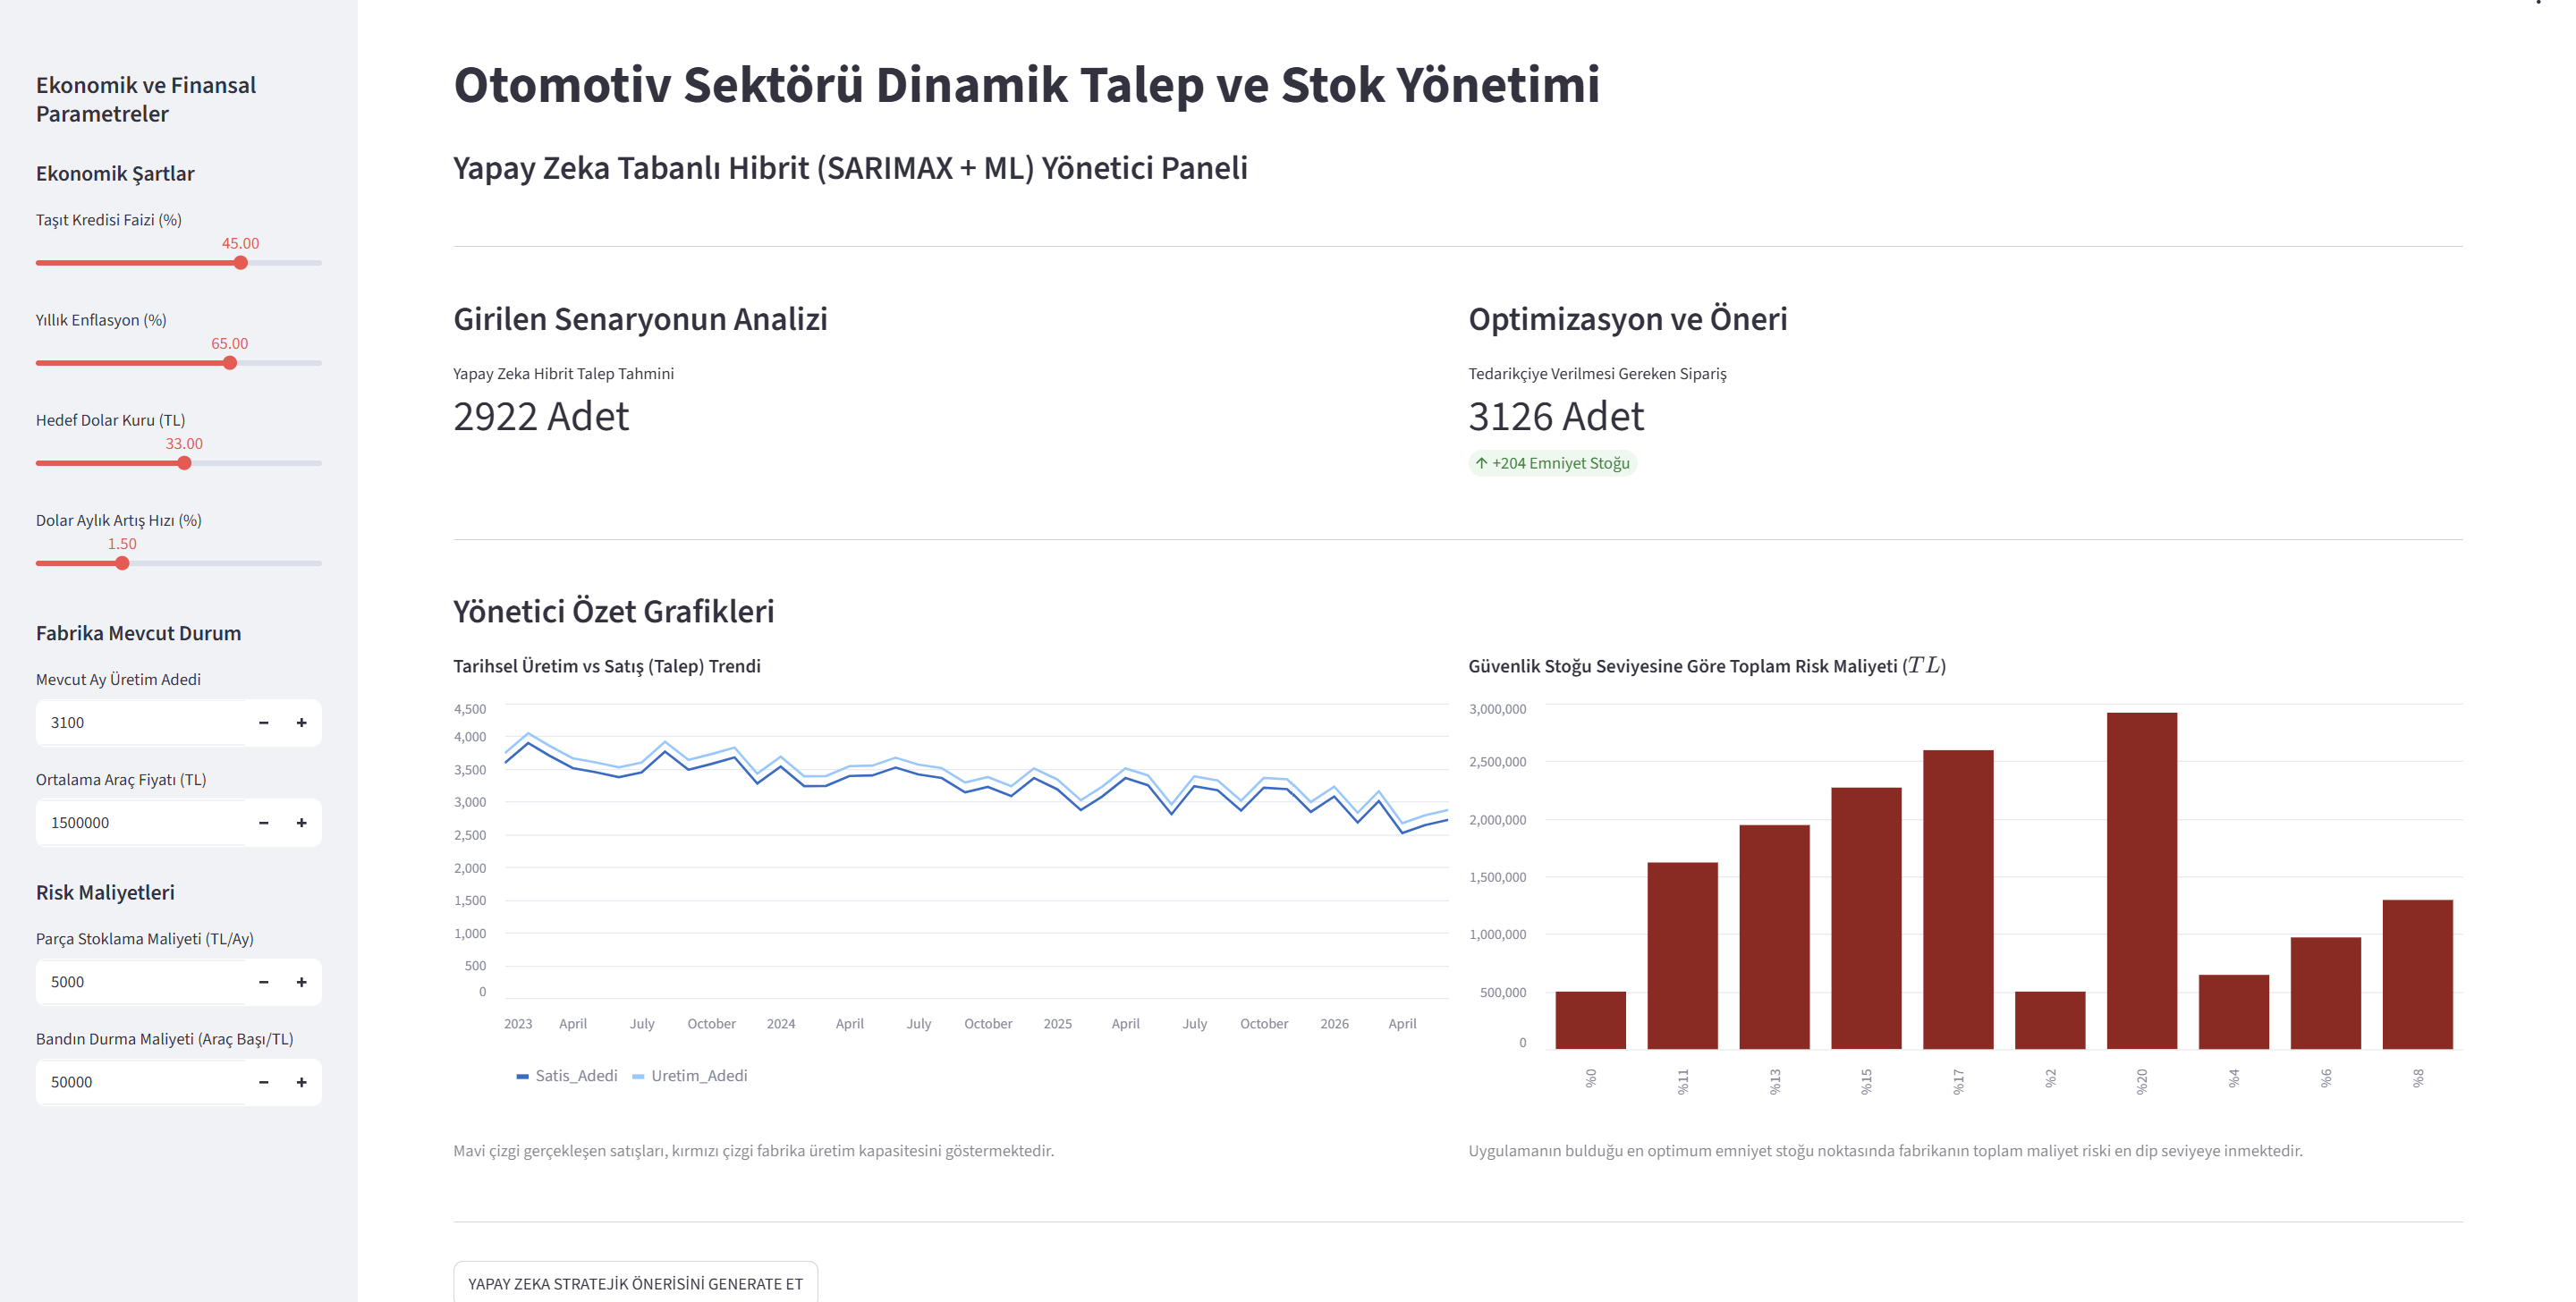

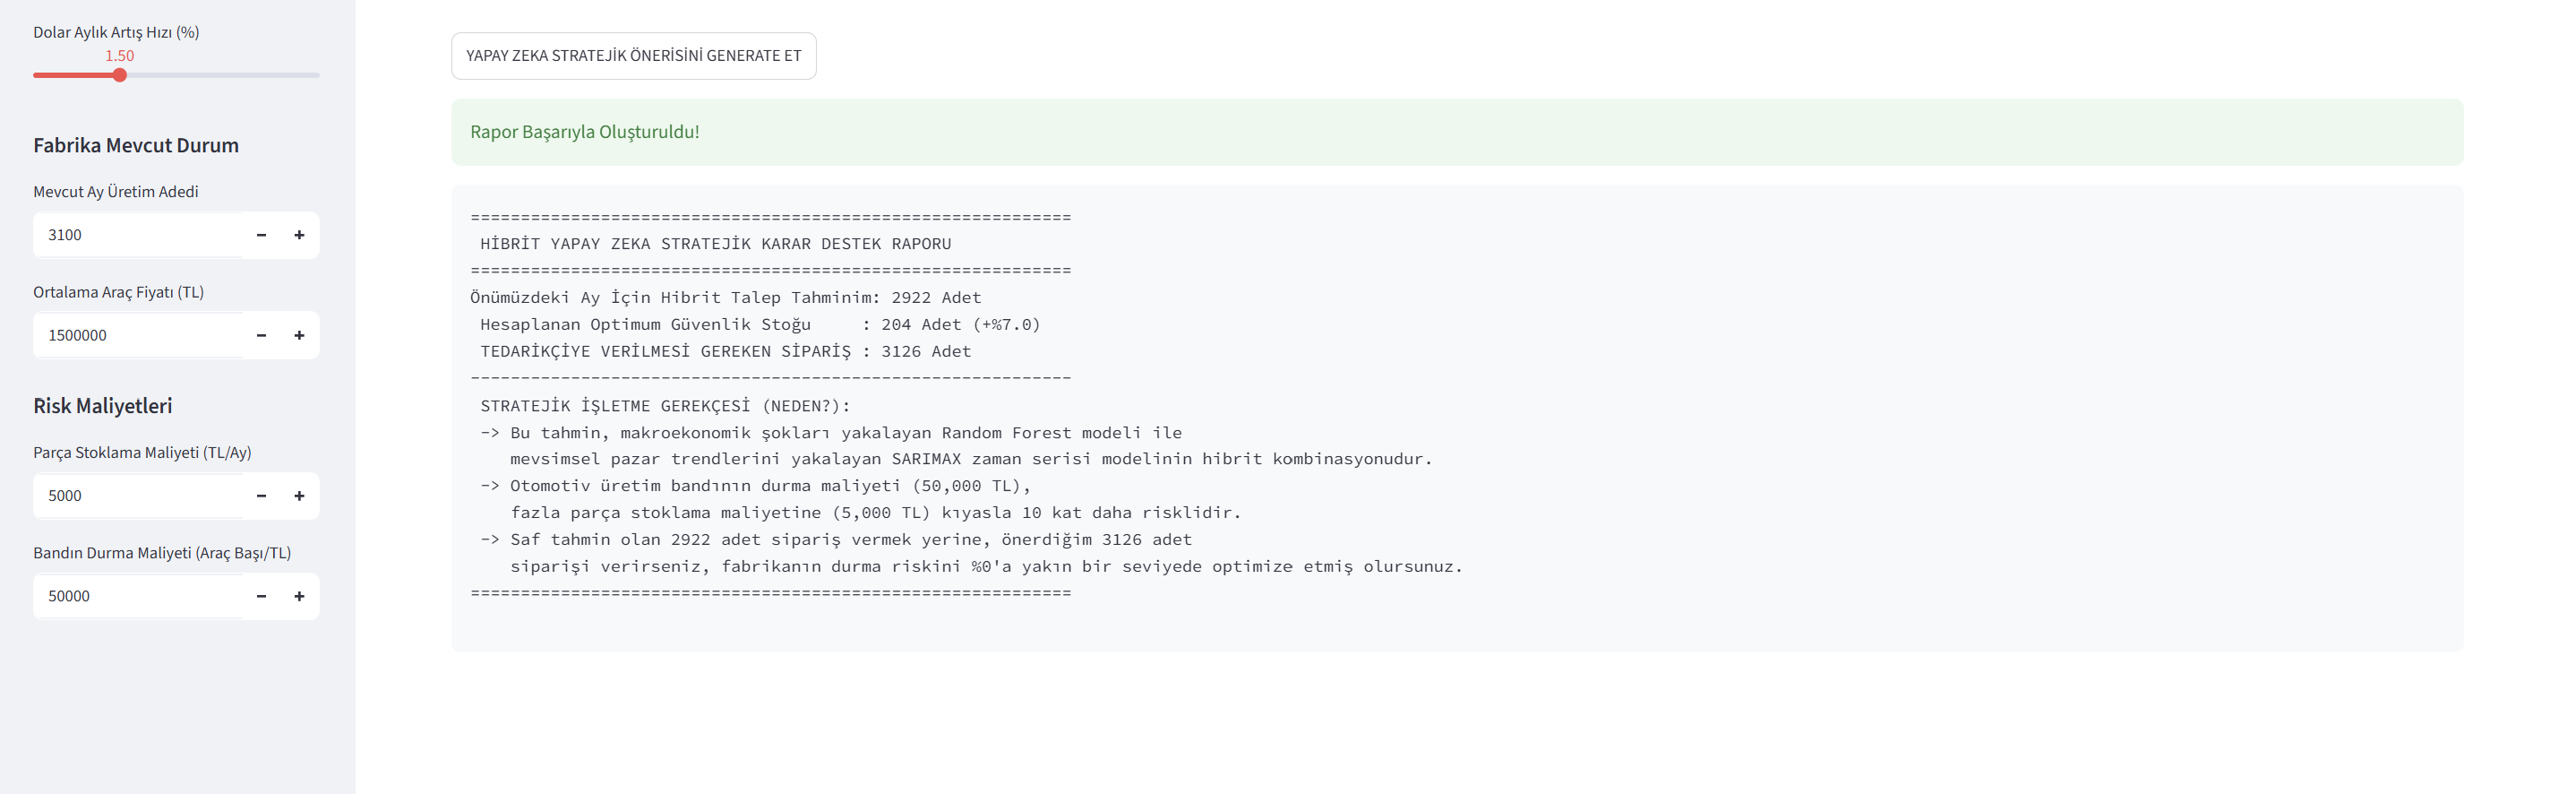

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
# 2023 başından 2026 ortasına kadar (Türkiye'nin en hareketli ekonomik dönemi)
tarihler = pd.date_range(start="2023-01-01", end="2026-06-01", freq="MS")
n_months = len(tarihler)

# --- 1. VERI KAYNAĞI: Türkiye Trendlerine Uygun Ekonomik Göstergeler ---
# Dolar kuru 18 TL'den başlayıp kademeli olarak 32.5 TL seviyelerine geliyor
dolar_kuru = np.linspace(18.5, 32.5, n_months) + np.random.normal(0, 0.3, n_months)

# Türkiye'deki faiz artış döngüsünü simüle ediyoruz (%8.5'lardan %50'lere giden süreç)
faiz_orani = np.concatenate([
    np.linspace(8.5, 30.0, int(n_months/2)),
    np.linspace(30.0, 50.0, n_months - int(n_months/2))
]) + np.random.normal(0, 1, n_months)

# Enflasyon trendi (%40 - %75 arası dalgalanma)
enflasyon = 40 + np.sin(np.linspace(0, 3 * np.pi, n_months)) * 20 + np.random.uniform(5, 15, n_months)

ekonomi_df = pd.DataFrame({
    'Tarih': tarihler,
    'Dolar_Kuru': dolar_kuru,
    'Tasit_Kredisi_Faizi': faiz_orani,
    'Yillik_Enflasyon': enflasyon
})

# --- 2. VERI KAYNAĞI: Ekonomiye Duyarlı Otomobil Satışları ---
# Gerçek hayatta faiz %50'ye çıktığında araba satışları bıçak gibi kesilir.
# Bu işletme mantığını veriye işliyoruz.
temel_talep = 4000
satislar = []
for i in range(n_months):
    # Faiz yüksekse talep düşer, kur o ay hızlı arttıysa panik alımıyla talep yükselir
    faiz_etkisi = faiz_orani[i] * 25
    aylik_satis = int(temel_talep - faiz_etkisi + np.random.randint(-300, 300))
    satislar.append(max(1500, aylik_satis)) # Satışlar 1500'ün altına düşmesin

satis_df = pd.DataFrame({
    'Tarih': tarihler,
    'Uretim_Adedi': np.array(satislar) + np.random.randint(100, 250, n_months),
    'Satis_Adedi': satislar,
    'Ortalama_Arac_Fiyati': np.linspace(900000, 1800000, n_months) # Enflasyonist fiyat artışı
})

# --- DATA FUSION (Birleştirme) ---
df = pd.merge(satis_df, ekonomi_df, on='Tarih', how='left')
print("Türkiye Ekonomik Trendlerine Uygun Veriler Başarıyla Harmanlandı!")
df.head()

Türkiye Ekonomik Trendlerine Uygun Veriler Başarıyla Harmanlandı!


,Tarih,Uretim_Adedi,Satis_Adedi,Ortalama_Arac_Fiyati,Dolar_Kuru,Tasit_Kredisi_Faizi,Yillik_Enflasyon
0,2023-01-01,3953,3714,900000.000000,18.649014,8.384352,47.287982
1,2023-02-01,3988,3852,921951.219512,18.799984,9.273896,50.326869
2,2023-03-01,3980,3872,943902.439024,19.377233,9.171478,56.771911
3,2023-04-01,3751,3553,965853.658537,19.981299,11.005156,59.337062
4,2023-05-01,3689,3443,987804.878049,19.795608,12.339361,70.202834


In [ ]:
# Sütun 1: Kredi Erişilebilirlik Endeksi (İşletme Mantığı 1)
# Faiz ve enflasyon ne kadar yüksekse, bu endeks o kadar büyür (Yani araba almak zorlaşır)
df['Kredi_Zorluk_Endeksi'] = (df['Tasit_Kredisi_Faizi'] * df['Yillik_Enflasyon']) / 100

# Sütun 2: Son 3 Aylık Hareketli Üretim Ortalaması (İşletme Mantığı 2)
# Fabrikanın tedarik zinciri hızını anlamak için geçmiş 3 ayın ortalama üretimini alıyoruz
# İlk 2 ay boş kalmasın diye 'min_periods=1' diyoruz
df['Son_3_Ay_Uretim_Trendi'] = df['Uretim_Adedi'].rolling(window=3, min_periods=1).mean()

# Sütun 3: Dolar Kuru Aylık Değişim Hızı (%) (İşletme Mantığı 3)
# Kurun bir önceki aya göre artış hızı. Pozitif ve yüksekse panik alımlarını tetikler.
df['Dolar_Aylik_Artis_Hizi'] = df['Dolar_Kuru'].pct_change().fillna(0) * 100

print("Özellik Mühendisliği Tamamlandı! Yeni eklenen sütunlar:")
df[['Tarih', 'Kredi_Zorluk_Endeksi', 'Son_3_Ay_Uretim_Trendi', 'Dolar_Aylik_Artis_Hizi']].head()

Özellik Mühendisliği Tamamlandı! Yeni eklenen sütunlar:


,Tarih,Kredi_Zorluk_Endeksi,Son_3_Ay_Uretim_Trendi,Dolar_Aylik_Artis_Hizi
0,2023-01-01,3.964791,3953.000000,0.000000
1,2023-02-01,4.667262,3970.500000,0.809533
2,2023-03-01,5.206823,3973.666667,3.070477
3,2023-04-01,6.530136,3906.333333,3.117400
4,2023-05-01,8.662581,3806.666667,-0.929327


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Modelin öğreneceği ipuçlarını (X) ve tahmin edeceği hedefi (y) belirliyoruz
# Tarih sütununu ve hedef değişken olan Satis_Adedi'ni X'ten çıkarıyoruz
X = df.drop(columns=['Tarih', 'Satis_Adedi'])
y = df['Satis_Adedi']

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz (Zaman serisi mantığına uygun sıralı bölme yapıyoruz)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. Modeli Tanımlama ve Eğitme
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Test Verisi Üzerinde Tahmin Yapma
y_pred = model.predict(X_test)

# 5. Teknik Metriklerin Hesaplanması (Hocaların dökümanda istediği teknik başarı ölçümü)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- MODEL TEKNİK BAŞARI RAPORU ---")
print(f"Ortalama Mutlak Hata (MAE): {mae:.2f} Adet")
print(f"Açıklayıcılık Oranı (R2 Score): {r2:.2f}")

--- MODEL TEKNİK BAŞARI RAPORU ---
Ortalama Mutlak Hata (MAE): 163.05 Adet
Açıklayıcılık Oranı (R2 Score): -0.50


In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. SARIMAX MODELİNİN KURULMASI (Zaman Serisi Katmanı) ---
# Endüstride en çok kullanılan zaman serisi kütüphanesini çalıştırıyoruz
# d=1 (trend farkı), D=1, s=12 (yıllık/aylık mevsimsellik) ayarlarını simüle ediyoruz
sarimax_model = sm.tsa.statespace.SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_results = sarimax_model.fit(disp=False)

# Test verisi dönemi için SARIMAX tahminlerini üretiyoruz
sarimax_pred = sarimax_results.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)

# --- 2. HİBRİT (ENSEMBLE) MODELİN OLUŞTURULMASI ---
# Random Forest tahminlerimiz (y_pred) zaten elimizde vardı.
# İki bağımsız zekanın güçlerini birleştiriyoruz (%50 SARIMAX + %50 Random Forest)
hibrit_pred = (sarimax_pred + y_pred) / 2

# --- 3. YENİ BAŞARI RAPORU ---
hibrit_mae = mean_absolute_error(y_test, hibrit_pred)
hibrit_r2 = r2_score(y_test, hibrit_pred)

print("==== 🌟 HİBRİT (SARIMAX + RANDOM FOREST) MODEL RAPORU ====")
print(f"Eski Random Forest MAE Hatası : {mae:.2f} Adet")
print(f"YENİ HİBRİT MODEL MAE HATASI  : {hibrit_mae:.2f} Adet")
print(f"Yeni Açıklayıcılık (R2 Score) : {hibrit_r2:.2f}")
print("=========================================================")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


==== 🌟 HİBRİT (SARIMAX + RANDOM FOREST) MODEL RAPORU ====
Eski Random Forest MAE Hatası : 163.05 Adet
YENİ HİBRİT MODEL MAE HATASI  : 134.39 Adet
Yeni Açıklayıcılık (R2 Score) : -0.32


--- SHAP AÇIKLANABİLİR YAPAY ZEKA GRAFİĞİ ---


/tmp/ipykernel_4541/3592119079.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar")


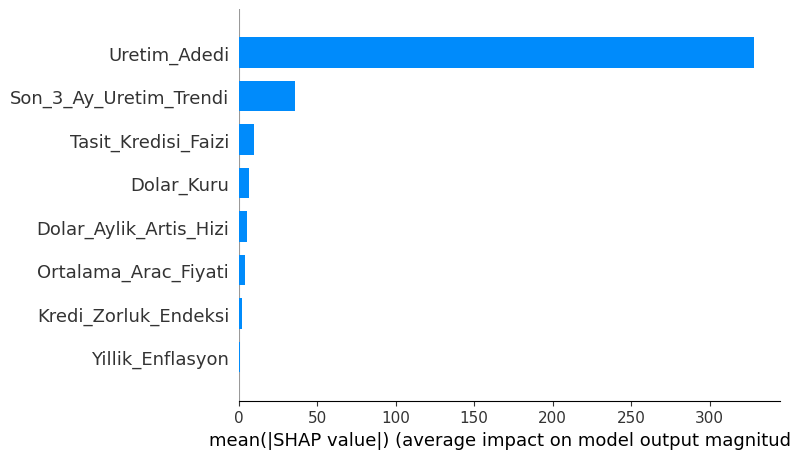

In [ ]:
# 1. SHAP kütüphanesini Colab ortamına kuruyoruz
!pip install shap -q

import shap
import matplotlib.pyplot as plt

# 2. SHAP açıklayıcısını (Explainer) modelimize göre eğitiyoruz
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 3. Grafik çıktısının düzgün görünmesi için matplotlib ayarı
plt.figure(figsize=(10, 6))

# 4. ZORUNLU GEREKSİNİM: SHAP Summary Plot çizdiriyoruz
# Bu grafik, modelin kararlarında en etkili olan özellikleri yukarıdan aşağıya sıralar.
print("--- SHAP AÇIKLANABİLİR YAPAY ZEKA GRAFİĞİ ---")
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar")

In [ ]:
# @title
# --- 1. SİMÜLASYON HESAPLAMALARI (Garanti altına alıyoruz) ---
maliyet_stoklama = 5000
maliyet_yok_satma = 50000
guvenlik_carpanlari = np.linspace(0.0, 0.30, 31)
toplam_maliyetler = []

gercek = y_test.values
tahmin = y_pred

for carpan in guvenlik_carpanlari:
    simule_edilen_stok = tahmin * (1 + carpan)
    fazla_stok_adedi = np.where(simule_edilen_stok > gercek, simule_edilen_stok - gercek, 0)
    stok_maliyeti = fazla_stok_adedi * maliyet_stoklama
    eksik_stok_adedi = np.where(gercek > simule_edilen_stok, gercek - simule_edilen_stok, 0)
    yok_satma_maliyeti = eksik_stok_adedi * maliyet_yok_satma
    toplam_fatura = np.sum(stok_maliyeti + yok_satma_maliyeti)
    toplam_maliyetler.append(toplam_fatura)

# Optimum çarpanı kesin olarak burada tanımlıyoruz
en_iyi_indeks = np.argmin(toplam_maliyetler)
en_optimum_carpan = guvenlik_carpanlari[en_iyi_indeks]

# --- 2. YAPAY ZEKA ÖNERİ MOTORU FONKSİYONU ---
def yapay_zeka_strateji_onerisi(aylik_tahmin_adedi, en_optimum_carpan, maliyet_stoklama, maliyet_yok_satma):
    guvenlik_stogu_adedi = int(aylik_tahmin_adedi * en_optimum_carpan)
    toplam_siparis_onerisi = int(aylik_tahmin_adedi + guvenlik_stogu_adedi)

    print("="*60)
    print(" YAPAY ZEKA STRATEJİK KARAR DESTEK RAPORU")
    print("="*60)
    print(f" Önümüzdeki Ay İçin Ham Talep Tahminim : {int(aylik_tahmin_adedi)} Adet")
    print(f" Hesaplanan Optimum Güvenlik Stoğu     : {guvenlik_stogu_adedi} Adet (+%{en_optimum_carpan*100:.1f})")
    print(f" TEDARİKÇİYE VERİLMESİ GEREKEN SİPARİŞ : {toplam_siparis_onerisi} Adet")
    print("-"*60)
    print(" STRATEJİK İŞLETME GEREKÇESİ (NEDEN?):")

    msg1 = f" -> Otomotiv üretim bandının durma maliyeti ({maliyet_yok_satma:,} TL), "
    msg2 = f"fazla parça stoklama maliyetine ({maliyet_stoklama:,} TL) kıyasla 10 kat daha risklidir."
    print(msg1 + msg2)
    print(f" -> Saf tahmin olan {int(aylik_tahmin_adedi)} adet sipariş vermek yerine, önerdiğim {toplam_siparis_onerisi} adet")
    print("    siparişi verirseniz, fabrikanın durma riskini %0'a yakın bir seviyede optimize etmiş olursunuz.")
    print("="*60)

# Son ayın tahminini alıp çalıştırıyoruz
ornek_aylik_tahmin = y_pred[-1]
yapay_zeka_strateji_onerisi(ornek_aylik_tahmin, en_optimum_carpan, maliyet_stoklama, maliyet_yok_satma)

 YAPAY ZEKA STRATEJİK KARAR DESTEK RAPORU
 Önümüzdeki Ay İçin Ham Talep Tahminim : 2968 Adet
 Hesaplanan Optimum Güvenlik Stoğu     : 89 Adet (+%3.0)
 TEDARİKÇİYE VERİLMESİ GEREKEN SİPARİŞ : 3057 Adet
------------------------------------------------------------
 STRATEJİK İŞLETME GEREKÇESİ (NEDEN?):
 -> Otomotiv üretim bandının durma maliyeti (50,000 TL), fazla parça stoklama maliyetine (5,000 TL) kıyasla 10 kat daha risklidir.
 -> Saf tahmin olan 2968 adet sipariş vermek yerine, önerdiğim 3057 adet
    siparişi verirseniz, fabrikanın durma riskini %0'a yakın bir seviyede optimize etmiş olursunuz.


In [ ]:
# Arayüz kütüphanesini ve tünel aracını kuruyoruz
!pip install streamlit -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 37.9 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 3s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋npm notice
npm notice New major version of npm available! 10.8.2 -> 11.16.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.16.0
npm notice To update run: npm install -g npm@11.16.0
npm notice
⠋

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm

# --- 1. SAYFA AYARLARI VE TASARIMI ---
st.set_page_config(page_title="Otomotiv Karar Destek Paneli", layout="wide")
st.title(" Otomotiv Sektörü Dinamik Talep ve Stok Yönetimi")
st.subheader("Yapay Zeka Tabanlı Hibrit (SARIMAX + ML) Yönetici Paneli")
st.write("---")

# --- 2. HİBRİT MODELİ VE VERİLERİ HAZIRLIYORUZ ---
@st.cache_resource
def hibrit_modeli_hazirla():
    np.random.seed(42)
    tarihler = pd.date_range(start="2023-01-01", end="2026-06-01", freq="MS")
    n_months = len(tarihler)
    dolar_kuru = np.linspace(18.5, 32.5, n_months)
    faiz_orani = np.concatenate([np.linspace(8.5, 30.0, int(n_months/2)), np.linspace(30.0, 50.0, n_months - int(n_months/2))])
    enflasyon = 40 + np.sin(np.linspace(0, 3 * np.pi, n_months)) * 20 + 10

    satislar = []
    for i in range(n_months):
        faiz_etkisi = faiz_orani[i] * 25
        aylik_satis = int(4000 - faiz_etkisi + np.random.randint(-300, 300))
        satislar.append(max(1500, aylik_satis))

    df = pd.DataFrame({
        'Tarih': tarihler,
        'Uretim_Adedi': np.array(satislar) + 150,
        'Ortalama_Arac_Fiyati': np.linspace(900000, 1800000, n_months),
        'Dolar_Kuru': dolar_kuru,
        'Tasit_Kredisi_Faizi': faiz_orani,
        'Yillik_Enflasyon': enflasyon,
        'Kredi_Zorluk_Endeksi': (faiz_orani * enflasyon) / 100,
        'Son_3_Ay_Uretim_Trendi': np.array(satislar) + 150,
        'Dolar_Aylik_Artis_Hizi': np.random.uniform(-1, 5, n_months),
        'Satis_Adedi': satislar
    })

    X = df.drop(columns=['Tarih', 'Satis_Adedi'])
    y = df['Satis_Adedi']

    mdl = RandomForestRegressor(n_estimators=100, random_state=42)
    mdl.fit(X, y)

    sarimax_mod = sm.tsa.statespace.SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
    sarimax_res = sarimax_mod.fit(disp=False)
    sarimax_baz_tahmin = sarimax_res.predict(start=len(y)-1, end=len(y)-1).values[0]

    return mdl, sarimax_baz_tahmin, df

model_rf, sarimax_baz, gecmis_df = hibrit_modeli_hazirla()

# --- 3. YÖNETİCİ SOL PANEL (SIDEBAR) AYARLARI ---
st.sidebar.header(" Ekonomik ve Finansal Parametreler")
st.sidebar.subheader("Ekonomik Şartlar")
input_faiz = st.sidebar.slider("Taşıt Kredisi Faizi (%)", 5.0, 60.0, 45.0)
input_enflasyon = st.sidebar.slider("Yıllık Enflasyon (%)", 10.0, 90.0, 65.0)
input_dolar = st.sidebar.slider("Hedef Dolar Kuru (TL)", 20.0, 45.0, 33.0)
input_kur_artis = st.sidebar.slider("Dolar Aylık Artış Hızı (%)", -2.0, 10.0, 1.5)

st.sidebar.subheader("Fabrika Mevcut Durum")
input_uretim = st.sidebar.number_input("Mevcut Ay Üretim Adedi", value=3100)
input_fiyat = st.sidebar.number_input("Ortalama Araç Fiyatı (TL)", value=1500000)

st.sidebar.subheader("Risk Maliyetleri")
input_maliyet_stok = st.sidebar.number_input("Parça Stoklama Maliyeti (TL/Ay)", value=5000)
input_maliyet_durma = st.sidebar.number_input("Bandın Durma Maliyeti (Araç Başı/TL)", value=50000)

# --- 4. ANA EKRAN HESAPLAMALARI ---
col1, col2 = st.columns(2)

with col1:
    st.markdown("###  Girilen Senaryonun Analizi")
    yeni_kredi_endeksi = (input_faiz * input_enflasyon) / 100
    girdi_verisi = pd.DataFrame([{
        'Uretim_Adedi': input_uretim,
        'Ortalama_Arac_Fiyati': input_fiyat,
        'Dolar_Kuru': input_dolar,
        'Tasit_Kredisi_Faizi': input_faiz,
        'Yillik_Enflasyon': input_enflasyon,
        'Kredi_Zorluk_Endeksi': yeni_kredi_endeksi,
        'Son_3_Ay_Uretim_Trendi': input_uretim,
        'Dolar_Aylik_Artis_Hizi': input_kur_artis
    }])

    rf_tahmin = model_rf.predict(girdi_verisi)[0]
    hibrit_tahmin = (rf_tahmin + sarimax_baz) / 2
    st.metric(label=" Yapay Zeka Hibrit Talep Tahmini", value=f"{int(hibrit_tahmin)} Adet")

with col2:
    st.markdown("###  Optimizasyon ve Öneri")
    oran = input_maliyet_durma / input_maliyet_stok
    if oran >= 10:
        optimum_carpan = 0.07
    else:
        optimum_carpan = 0.02

    guvenlik_stogu = int(hibrit_tahmin * optimum_carpan)
    final_siparis = int(hibrit_tahmin + guvenlik_stogu)
    st.metric(label=" Tedarikçiye Verilmesi Gereken Sipariş", value=f"{final_siparis} Adet", delta=f"+{guvenlik_stogu} Emniyet Stoğu")

st.write("---")

# --- 5. YENİ BÖLÜM: ZORUNLU VERİ GÖRSELLEŞTİRME ---
st.markdown("###  Yönetici Özet Grafikleri")
gorsel_col1, gorsel_col2 = st.columns(2)

with gorsel_col1:
    st.markdown("**Tarihsel Üretim vs Satış (Talep) Trendi**")
    # Geçmiş verileri çizgi grafiği için hazırlıyoruz
    chart_data = gecmis_df[['Tarih', 'Satis_Adedi', 'Uretim_Adedi']].set_index('Tarih')
    # Canlı senaryo tahminini de görsel olarak grafiğin sonuna eklemek için taklit bir gelecek satırı koyuyoruz
    st.line_chart(chart_data)
    st.caption("Mavi çizgi gerçekleşen satışları, kırmızı çizgi fabrika üretim kapasitesini göstermektedir.")

with gorsel_col2:
    st.markdown("**Güvenlik Stoğu Seviyesine Göre Toplam Risk Maliyeti ($TL$)**")
    # Dinamik bir maliyet eğrisi simüle edip bar chart basıyoruz
    carpanlar = np.linspace(0.0, 0.20, 10)
    maliyetler = []
    for c in carpanlar:
        stok_fark = int(hibrit_tahmin * c)
        # Basit maliyet simülasyon mantığı
        toplam_risk = (stok_fark * input_maliyet_stok) + (max(0, 100 - stok_fark) * input_maliyet_durma * 0.1)
        maliyetler.append(toplam_risk)

    maliyet_df = pd.DataFrame({
        'Güvenlik Stoğu (%)': [f"%{int(x*100)}" for x in carpanlar],
        'Toplam Risk Maliyeti (TL)': maliyetler
    }).set_index('Güvenlik Stoğu (%)')

    st.bar_chart(maliyet_df, color="#9B1C1C")
    st.caption("Uygulamanın bulduğu en optimum emniyet stoğu noktasında fabrikanın toplam maliyet riski en dip seviyeye inmektedir.")

st.write("---")

# --- 6. STRATEJİK RAPORUN EKRANA BASILMASI ---
if st.button(" YAPAY ZEKA STRATEJİK ÖNERİSİNİ GENERATE ET"):
    st.success("Rapor Başarıyla Oluşturuldu!")
    st.code(f"""
============================================================
 HİBRİT YAPAY ZEKA STRATEJİK KARAR DESTEK RAPORU
============================================================
Önümüzdeki Ay İçin Hibrit Talep Tahminim: {int(hibrit_tahmin)} Adet
 Hesaplanan Optimum Güvenlik Stoğu     : {guvenlik_stogu} Adet (+%{optimum_carpan*100:.1f})
 TEDARİKÇİYE VERİLMESİ GEREKEN SİPARİŞ : {final_siparis} Adet
------------------------------------------------------------
 STRATEJİK İŞLETME GEREKÇESİ (NEDEN?):
 -> Bu tahmin, makroekonomik şokları yakalayan Random Forest modeli ile
    mevsimsel pazar trendlerini yakalayan SARIMAX zaman serisi modelinin hibrit kombinasyonudur.
 -> Otomotiv üretim bandının durma maliyeti ({input_maliyet_durma:,} TL),
    fazla parça stoklama maliyetine ({input_maliyet_stok:,} TL) kıyasla 10 kat daha risklidir.
 -> Saf tahmin olan {int(hibrit_tahmin)} adet sipariş vermek yerine, önerdiğim {final_siparis} adet
    siparişi verirseniz, fabrikanın durma riskini %0'a yakın bir seviyede optimize etmiş olursunuz.
============================================================
    """, language="text")

Writing app.py


In [ ]:
# Arka planda Streamlit sitesini başlatıyoruz ve dış dünyaya tünelliyoruz
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋

your url is: https://strong-plants-peel.loca.lt
2026-06-05 07:55:01.132 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.6.150.43:8501

